In [1]:
import pandas as pd
import re
import math
import cartopy.crs as ccrs
import cartopy
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import statsmodels.api as sm
import geopandas as gpd
from scipy import stats
import datetime
import seaborn as sns
from geopy.distance import distance
import geopandas as gpd
import rioxarray
from functools import reduce
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load ERA5 data

# NZ only study area data
monthly_misc = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/1969_2019_all.nc')
monthly_snowmelt = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/snow/snowmelt/1969_2019.nc')
monthly_runoff = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/runoff/total_runoff/1969_2019.nc')
monthly_snow = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/snow/1959_2021.nc')
monthly_temp = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/temp/1959_2019.nc')

monthly_era = xr.merge([monthly_misc,monthly_snowmelt,monthly_runoff,monthly_snow,monthly_temp])
seasonal_era = monthly_era.resample(time='Q-DEC').mean()

# interpolate ERA5 to finer spatial resolution
new_lon = np.linspace(seasonal_era.longitude[0], seasonal_era.longitude[-1], len(seasonal_era.longitude.values) * 10)
new_lat = np.linspace(seasonal_era.latitude[0], seasonal_era.latitude[-1], len(seasonal_era.latitude.values) * 10)

monthly_era_interp = monthly_era.interp(latitude=new_lat, longitude=new_lon,method='linear').sel(time=slice('1969', '2019'))
seasonal_era_interp = seasonal_era.interp(latitude=new_lat, longitude=new_lon,method='linear').sel(time=slice('1969', '2019'))

# load SEASONAL observed flow data
seasonal_flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
seasonal_flow_df.date = pd.to_datetime(seasonal_flow_df.date)
seasonal_flow_df.set_index('date', inplace=True)
seasonal_flow_df = seasonal_flow_df['1969':'2019'] 

# load metadata
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)
subset_meta = metadata_df.loc[[int(s) for s in seasonal_flow_df.columns]]
subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()
meta_df = gpd.GeoDataFrame(subset_meta,geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                          crs='EPSG:4326')

# load catchment shape data
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")
catchment_data = catchment_data.loc[catchment_data['SITE'].isin(seasonal_flow_df.columns)]
catchment_data.index = catchment_data['SITE']

In [3]:
# load MONTHLY observed flow data
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/daily/50yrs/full_records.csv')
flow_df.Date = pd.to_datetime(flow_df.Date)
flow_df.set_index('Date', inplace=True)
flow_df = flow_df['1969':'2019']
monthly_flow_df = flow_df.resample('M').mean()
monthly_flow_df.index=monthly_flow_df.index.map(lambda x : x.replace(day=1))
#monthly_flow_df.fillna(monthly_flow_df.mean(), inplace=True)


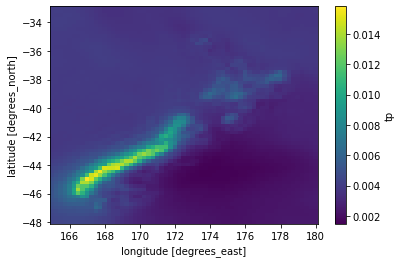

In [67]:
seasonal_era['tp'].mean('time').plot()

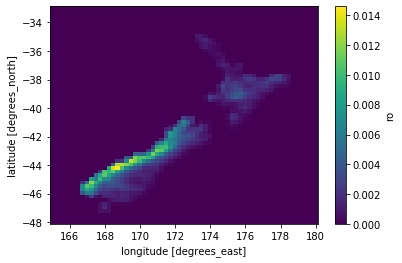

In [70]:
seasonal_era['ro'].mean('time').plot()

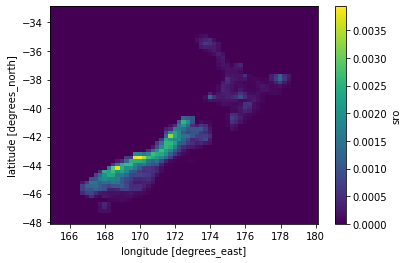

In [69]:
seasonal_era['sro'].mean('time').plot()

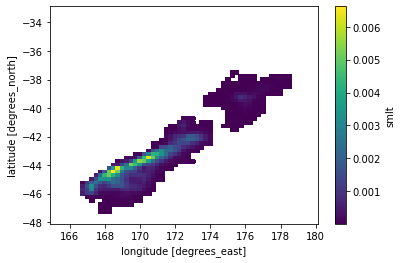

In [45]:
seasonal_era['smlt'].where(seasonal_era['smlt'] != 9.313226e-10).mean('time').plot()

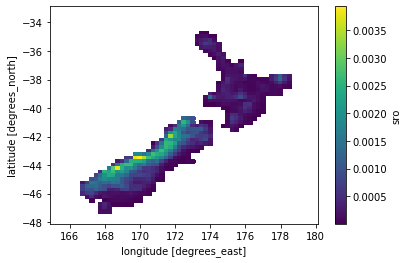

In [47]:
seasonal_era['sro'].where(seasonal_era['sro'] != 0.0).mean('time').plot()

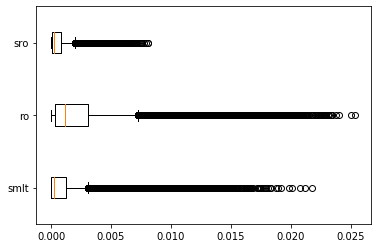

In [74]:
smlt_vals = seasonal_era['smlt'].where(seasonal_era['smlt'] != 9.313226e-10).values.flatten()
filtered_smlt = smlt_vals[~np.isnan(smlt_vals)]
sro_vals = seasonal_era['sro'].where(seasonal_era['sro'] != 0.0).values.flatten()
filtered_sro = sro_vals[~np.isnan(sro_vals)]
ro_vals = seasonal_era['ro'].where(seasonal_era['ro'] != 0.0).values.flatten()
filtered_ro = ro_vals[~np.isnan(ro_vals)]

plt.boxplot([filtered_smlt, filtered_ro, filtered_sro],labels=['smlt','ro','sro'],vert=False)
plt.show()

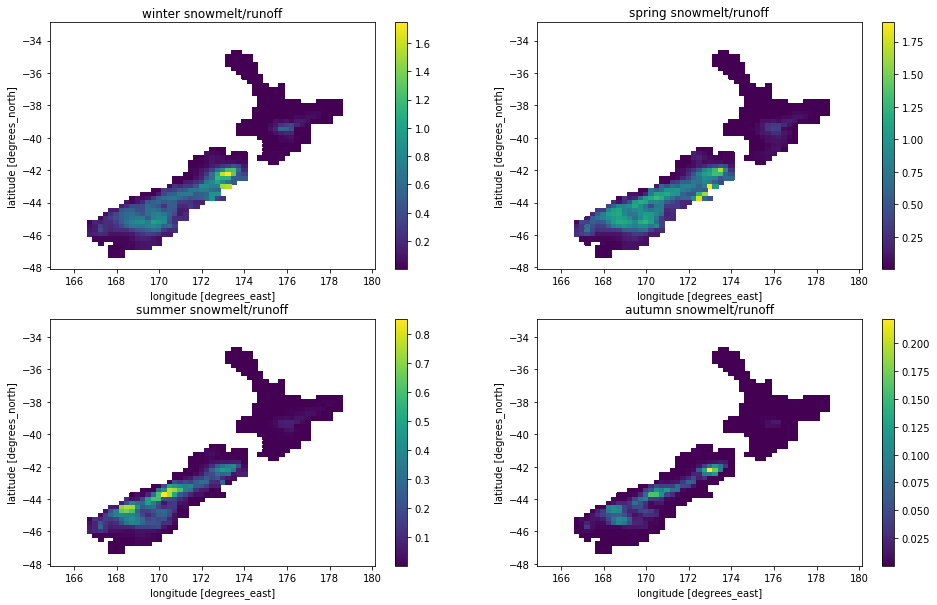

In [95]:
fig,axs = plt.subplots(2,2,figsize=(16,10))
axs = axs.flatten()

seasons = {6:'winter',9:'spring',12:'summer',3:'autumn'}

for i,s in enumerate([6,9,12,3]):
    smlt = seasonal_era['smlt'].sel(time=seasonal_era['smlt'].time.dt.month.isin([s]))
    ro = seasonal_era['ro'].sel(time=seasonal_era['ro'].time.dt.month.isin([s]))

    (smlt/ro).mean('time').plot(ax=axs[i])
    axs[i].set_title(seasons[s] + " snowmelt/runoff")

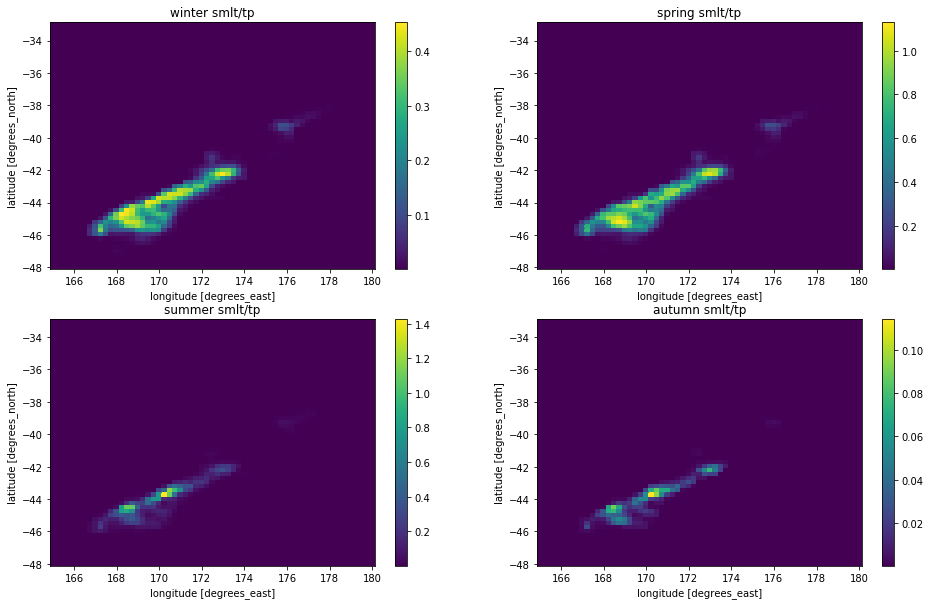

In [108]:
fig,axs = plt.subplots(2,2,figsize=(16,10))
axs = axs.flatten()

seasons = {6:'winter',9:'spring',12:'summer',3:'autumn'}

for i,s in enumerate([6,9,12,3]):
    smlt = seasonal_era['smlt'].sel(time=seasonal_era['smlt'].time.dt.month.isin([s])).mean('time')
    tp = seasonal_era['tp'].sel(time=seasonal_era['tp'].time.dt.month.isin([s])).mean('time')

    
    (smlt/tp).plot(ax=axs[i])
    axs[i].set_title(seasons[s] + " smlt/tp")

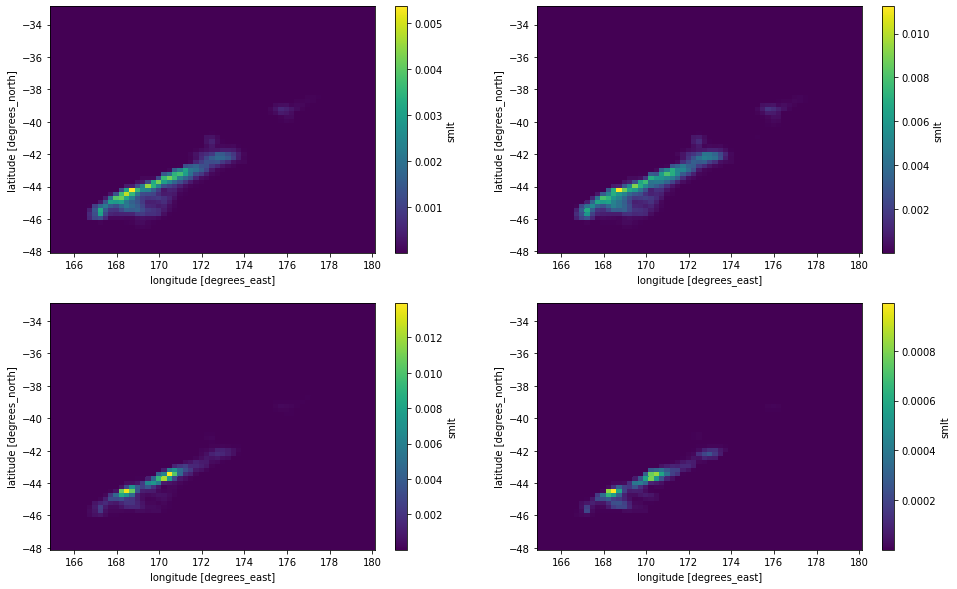

In [106]:
fig,axs = plt.subplots(2,2,figsize=(16,10))
axs = axs.flatten()

seasons = {6:'winter',9:'spring',12:'summer',3:'autumn'}

for i,s in enumerate([6,9,12,3]):
    smlt = seasonal_era['smlt'].sel(time=seasonal_era['smlt'].time.dt.month.isin([s])).mean('time').plot(ax=axs[i])

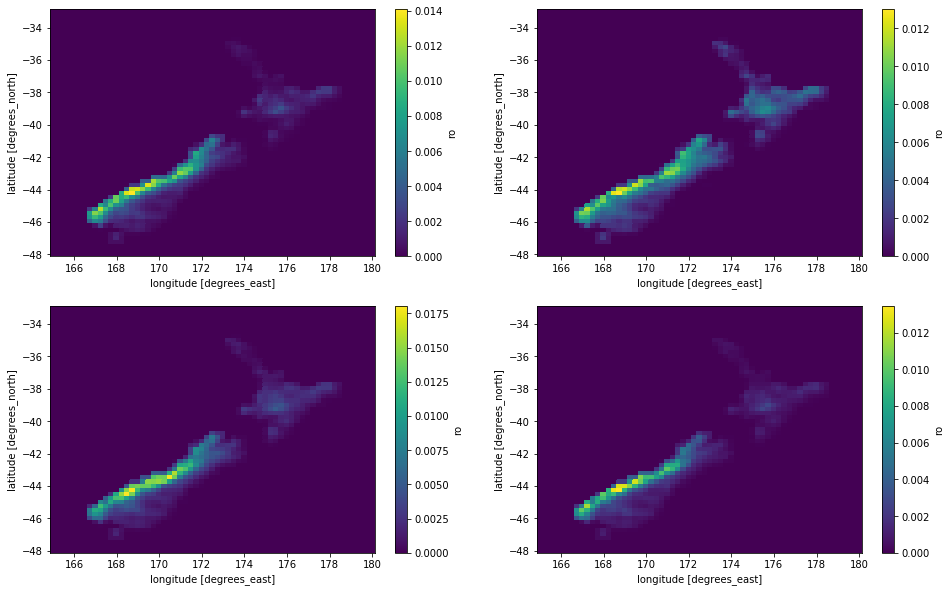

In [100]:
fig,axs = plt.subplots(2,2,figsize=(16,10))
axs = axs.flatten()

seasons = {6:'winter',9:'spring',12:'summer',3:'autumn'}

for i,s in enumerate([6,9,12,3]):
    ro = seasonal_era['ro'].sel(time=seasonal_era['ro'].time.dt.month.isin([s])).mean('time').plot(ax=axs[i])

In [ ]:
sro = monthly_era_interp['sro'].rio.write_crs("EPSG:4326")
sro.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

tp = monthly_era_interp['tp'].rio.write_crs("EPSG:4326")
tp.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

smlt = monthly_era_interp['smlt'].rio.write_crs("EPSG:4326")
smlt.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

ro = monthly_era_interp['ro'].rio.write_crs("EPSG:4326")
ro.rio.set_spatial_dims('longitude', 'latitude', inplace=True)


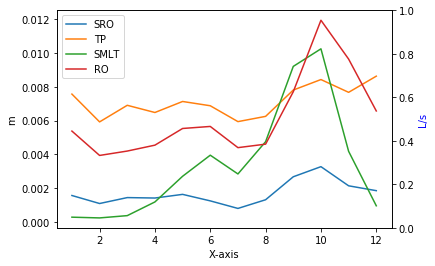

In [15]:
fig, ax1 = plt.subplots() 
ax1.set_xlabel('X-axis') 
ax1.set_ylabel('m') 

ax2 = ax1.twinx() 
ax2.set_ylabel('L/s', color = 'blue') 

for site in ['71120']:#,'71123','71132','75292','71129','71135']:

    obs_flow = monthly_flow_df[site].groupby(monthly_flow_df[site].index.month).mean()
    
    catchment_geo = catchment_data.loc[[float(site)]]

    clipped_sro = sro.rio.clip(catchment_geo.geometry,catchment_data.crs).mean(['longitude','latitude']).groupby(sro.time.dt.month).mean()
    clipped_tp = tp.rio.clip(catchment_geo.geometry,catchment_data.crs).mean(['longitude','latitude']).groupby(tp.time.dt.month).mean()
    clipped_smlt = smlt.rio.clip(catchment_geo.geometry,catchment_data.crs).mean(['longitude','latitude']).groupby(smlt.time.dt.month).mean()
    clipped_ro = ro.rio.clip(catchment_geo.geometry,catchment_data.crs).mean(['longitude','latitude']).groupby(ro.time.dt.month).mean()

    ax1.plot(clipped_sro.month, clipped_sro,label='surface runoff')
    ax1.plot(clipped_ro.month,clipped_ro,label='total runoff')
    ax1.plot(clipped_tp.month,clipped_tp,label='total precipitation')
    ax1.plot(clipped_smlt.month,clipped_smlt,label='snowmelt')

    ax1.legend()
    
    #ax2.plot(obs_flow,label='obs')
    #ax2.set_ylim(-1000,125000)
    #ax2.legend()
    


In [10]:
clipped_smlt.month.values

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

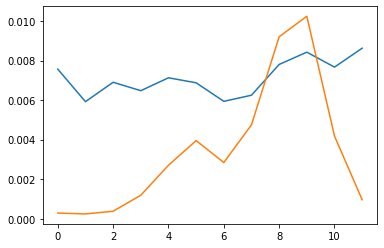

In [6]:
era_tp = monthly_era_interp['tp'].rio.write_crs("EPSG:4326")
era_tp.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

era_smlt = monthly_era_interp['smlt'].rio.write_crs("EPSG:4326")
era_smlt.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for site in ['71120']:#,'71123','71132','75292','71129','71135']:

    catchment_geo = catchment_data.loc[[float(site)]]

    clipped_tp = era_tp.rio.clip(catchment_geo.geometry,catchment_data.crs).mean(['longitude','latitude'])
    clipped_smlt = era_smlt.rio.clip(catchment_geo.geometry,catchment_data.crs).mean(['longitude','latitude'])

    plt.plot(clipped_tp.groupby(clipped_tp.time.dt.month).mean(), label='tp')
    plt.plot(clipped_smlt.groupby(clipped_smlt.time.dt.month).mean(), label='smlt')

plt.legend()

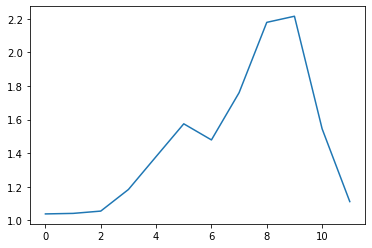

In [7]:
era_tp = monthly_era_interp['tp'].rio.write_crs("EPSG:4326")
era_tp.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

era_smlt = monthly_era_interp['smlt'].rio.write_crs("EPSG:4326")
era_smlt.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for site in ['71120']:#,'71123','71132','75292','71129','71135']:

    catchment_geo = catchment_data.loc[[float(site)]]

    clipped_tp = era_tp.rio.clip(catchment_geo.geometry,catchment_data.crs).mean(['longitude','latitude']).groupby(clipped_tp.time.dt.month).mean()
    clipped_smlt = era_smlt.rio.clip(catchment_geo.geometry,catchment_data.crs).mean(['longitude','latitude']).groupby(clipped_smlt.time.dt.month).mean()

    plt.plot((clipped_smlt + clipped_tp)/clipped_tp)


95101
93203
79713
79704
77505


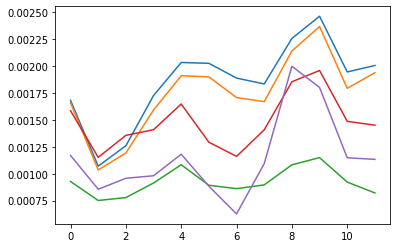

In [109]:
era_sro = monthly_era_interp['sro'].rio.write_crs("EPSG:4326")
era_sro.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for site in ['95101','93203','79713','79704','77505']:#,'60114','52916','57009','64602','65104','71116','75288']:

    #print(site)
    catchment_geo = catchment_data.loc[[float(site)]]

    clipped = era_sro.rio.clip(catchment_geo.geometry,catchment_data.crs)
    clipped_era = clipped.mean(['longitude','latitude'])
    
    plt.plot(clipped_era.groupby(clipped_era.time.dt.month).mean())




71120
71123
71132
75292
71129
71135


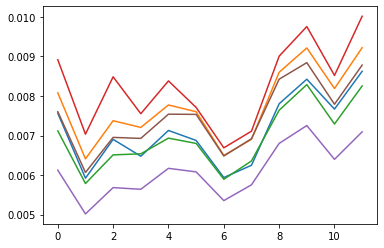

In [107]:
era_sro = monthly_era_interp['tp'].rio.write_crs("EPSG:4326")
era_sro.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for site in ['71120','71123','71132','75292','71129','71135']:

    print(site)
    catchment_geo = catchment_data.loc[[float(site)]]

    clipped = era_sro.rio.clip(catchment_geo.geometry,catchment_data.crs)
    clipped_era = clipped.mean(['longitude','latitude'])
    
    plt.plot(clipped_era.groupby(clipped_era.time.dt.month).mean())


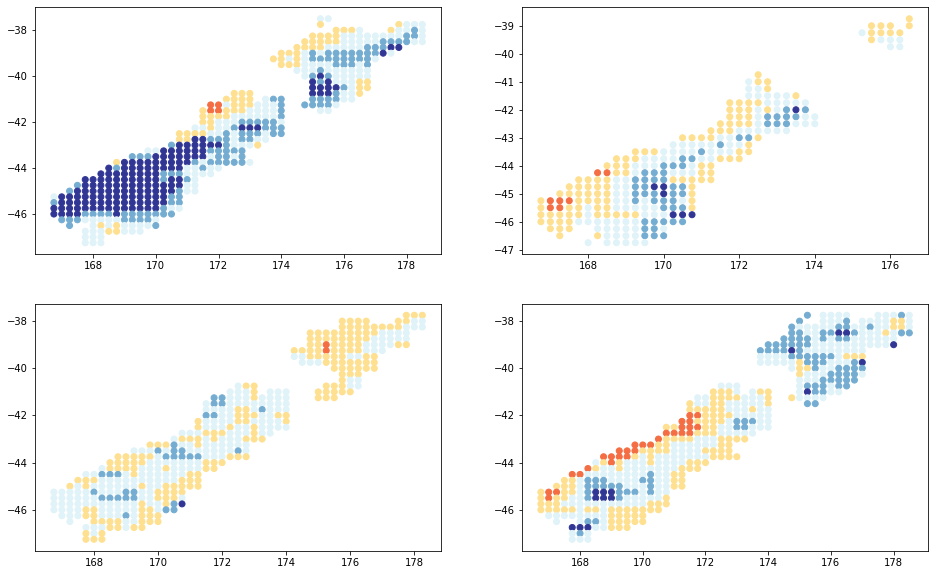

In [24]:
'''
SEASONAL correlations with interpolated ERA5 data
'''

fig,axs = plt.subplots(2,2,figsize=(16,10))
axs = axs.flatten()
seasons = {6:'winter',9:'spring',12:'summer',3:'autumn'}

s = 6

sro = seasonal_era['sro'].sel(time=seasonal_era['sro'].time.dt.month.isin([s]))
lats = sro.latitude.values.tolist()
lons = sro.longitude.values.tolist()
for i,comp_s in enumerate([6,3,12,9]):
    smlt = seasonal_era['smlt'].sel(time=seasonal_era['smlt'].time.dt.month.isin([comp_s]))

    lts = []
    lns = []
    vals = []
    for lat in lats:
        for lon in lons:
            sro_ts = sro.sel(latitude=lat,longitude=lon).values.tolist()
            smlt_ts = smlt.sel(latitude=lat,longitude=lon).values.tolist()

            (r,p) = stats.pearsonr(sro_ts,smlt_ts)

            lts.append(lat)
            lns.append(lon)
            vals.append(r)
                
    axs[i].scatter(lns,lts,c=vals,cmap=plt.cm.get_cmap('RdYlBu', 6),vmin=-0.6,vmax=0.6)
                


In [12]:
sro

<xarray.DataArray 'sro' (time: 51, latitude: 61, longitude: 61)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 1969-06-30 1970-06-30 ... 2019-06-30
  * latitude   (latitude) float32 -33.0 -33.25 -33.5 ... -47.5 -47.75 -48.0
  * longitude  (longitude) float32 165.0 165.25 165.5 ... 179.5 179.75 180.0

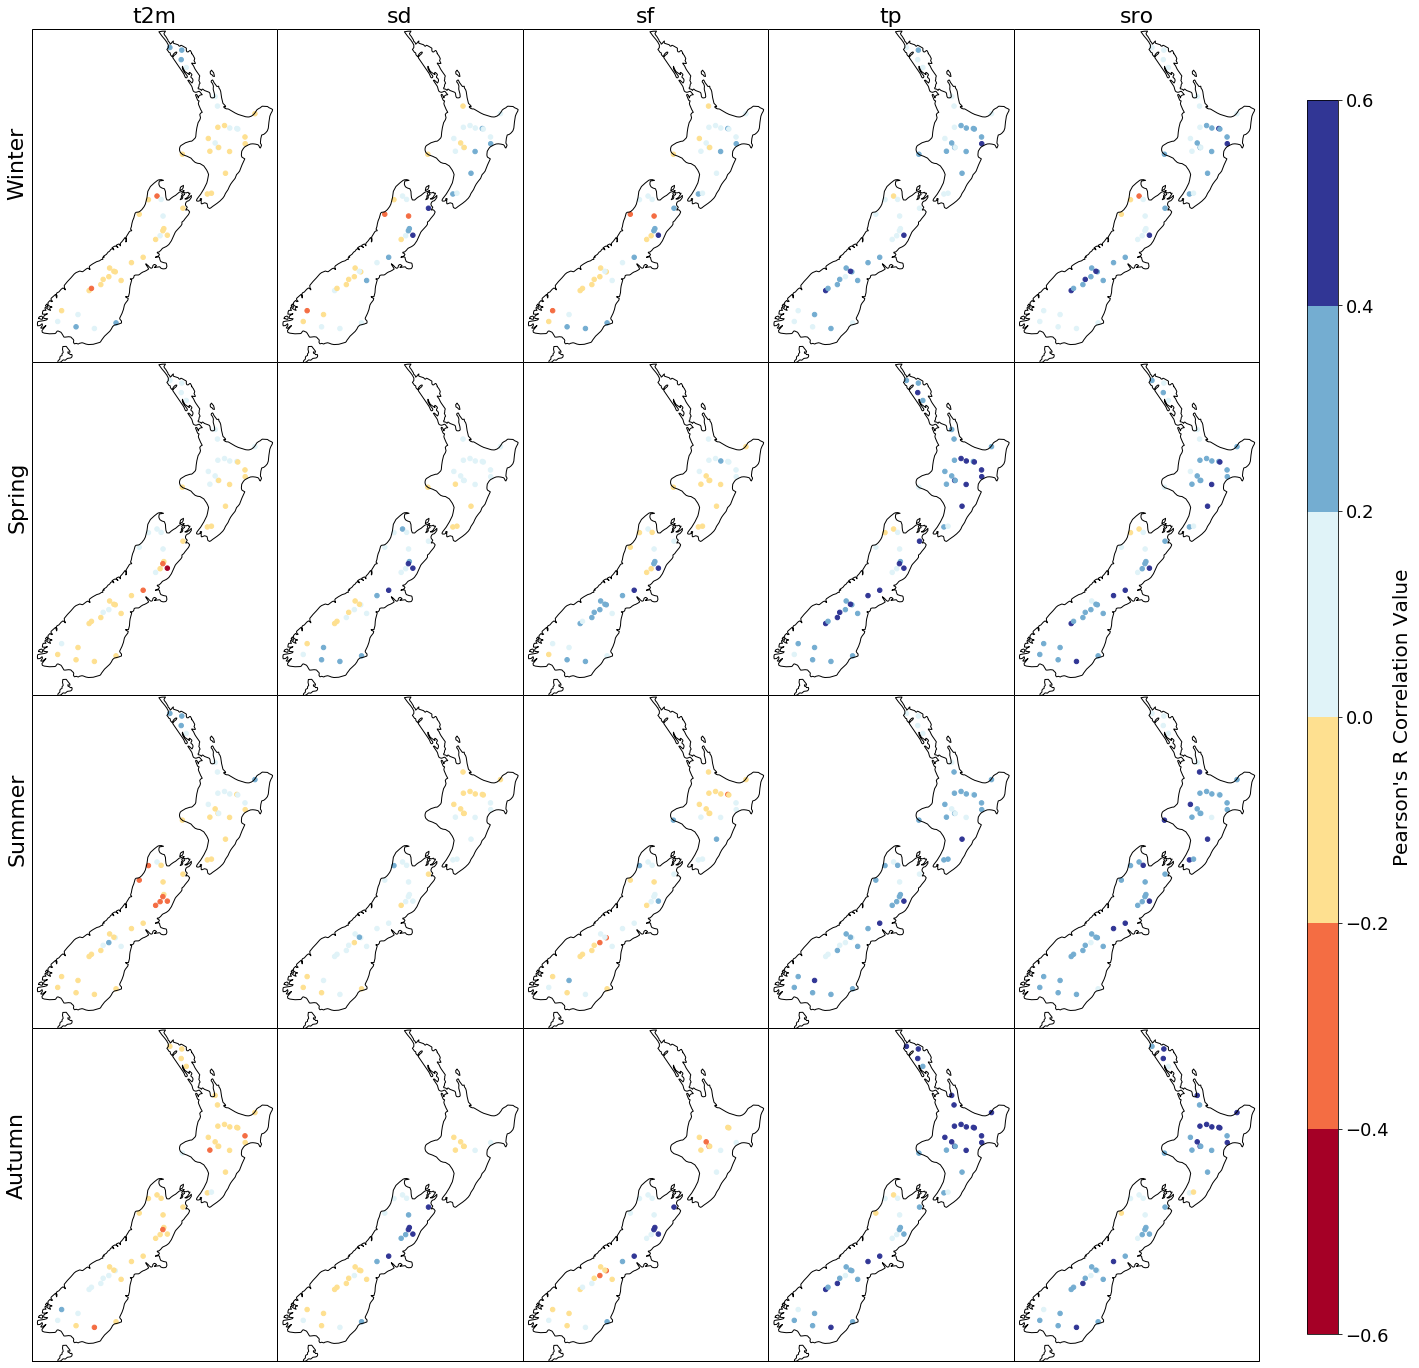

In [6]:
'''
SEASONAL correlations with interpolated ERA5 data
'''

crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
#catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)

fig, axs = plt.subplots(4,5,figsize=(22,24.5),subplot_kw={'projection': crs})

indices = ['t2m','sd','sf','tp','sro']

for i,s in enumerate([6,9,12,3]):
    flow_season = seasonal_flow_df[seasonal_flow_df.index.month == s]
    era_season = seasonal_era_interp.sel(time=seasonal_era_interp.time.dt.month.isin([s]))
        
    for j,index in enumerate(indices):
        
        if index in ['Z1','M1']:
            msl_season = seasonal_msl_ts[index][seasonal_msl_ts.index.month == s]['1969':'2019']
            
        else:
            era_index = era_season[index].rio.write_crs("EPSG:4326")
            era_index.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

        lons = []
        lats = []
        corr = []
        
        for site in flow_season:

            if site == '4901':
                continue
                
            detrended_flow = detrend(flow_season[site])
                
            if index in ['Z1','M1']:
                (r,p) = stats.pearsonr(detrended_flow,msl_season.values.tolist())
            else:
                catchment_geo = catchment_data.loc[[float(site)]]
                clipped_era = era_index.rio.clip(catchment_geo.geometry,catchment_data.crs)
            
                clipped_ts = clipped_era.mean(['longitude','latitude']).values.tolist()

                (r,p) = stats.pearsonr(detrended_flow,clipped_ts)
              
            corr.append(r)
            lats.append(meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1])
            lons.append(meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0])
    
        axs[i][j].coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
        axs[i][j].set_xlim([18500000,19900000])
        axs[i][j].set_ylim([-5950000,-4050000])

        im = axs[i][j].scatter(lons,lats,marker='.',s=80,c=corr,cmap=plt.cm.get_cmap('RdYlBu', 6),vmin=-0.6,vmax=0.6)

        if j == 0:
            axs[i][j].text(-0.1,0.5,{3:'Autumn',6:'Winter',9:'Spring',12:'Summer'}[s],
                           rotation='vertical',transform=axs[i][j].transAxes,
                           fontsize=22)
            
        if i == 0:
            axs[i][j].set_title(index, fontsize=22)
            
cax = fig.add_axes([.93,0.14,.02,.7])
cbar = fig.colorbar(im, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Pearson\'s R Correlation Value',size=20)

plt.subplots_adjust(wspace=0, hspace=0)
        
#plt.savefig("Figure8_interp.png",dpi=300,bbox_inches='tight')


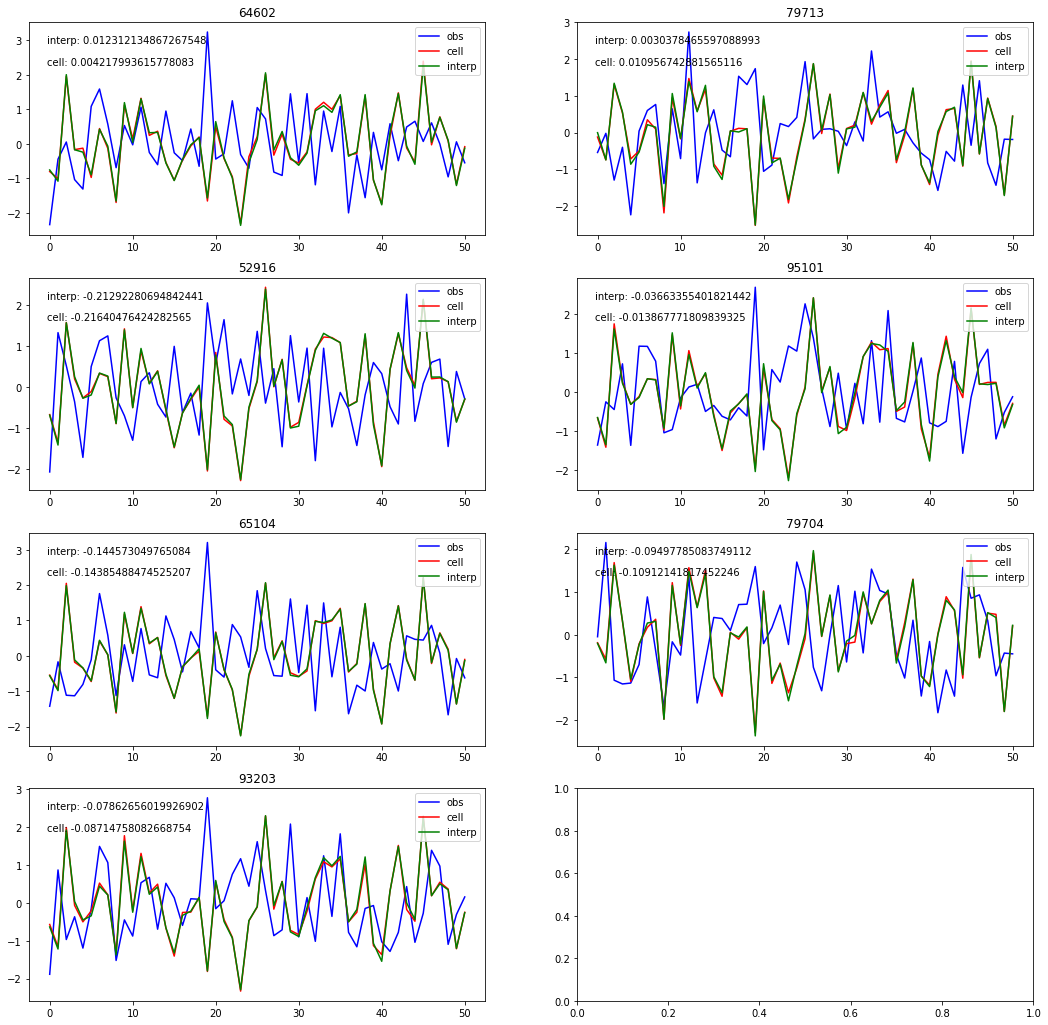

In [11]:
from scipy import stats

fig, ax = plt.subplots(4,2,figsize=(18,18))
axs = ax.flatten()

index = 't2m'#'tp','tcsw','sro']
era_index = seasonal_era[index]
era_interp_index = seasonal_era_interp[index].rio.write_crs("EPSG:4326")
era_interp_index.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for s in [6]:#,9,12,3]):
    era_season = era_index.sel(time=era_index.time.dt.month.isin([s]))
    era_interp_season = era_interp_index.sel(time=era_interp_index.time.dt.month.isin([s]))
    flow_season = seasonal_flow_df[seasonal_flow_df.index.month == s]['1969':'2019'] 
        
    for i,site in enumerate(['64602', '79713', '52916', '95101', '65104', '79704', '93203', ]):
        
        detrended_flow = detrend(flow_season[site].values.tolist())
        
        gauge_coords = [float(metadata_df.loc[int(site)]['centroid_lat']),float(metadata_df.loc[int(site)]['centroid_lon'])]

        cell = era_season.sel(latitude=gauge_coords[0],longitude=gauge_coords[1],method='nearest')
        
        catchment_geo = catchment_data.loc[[float(site)]]
        clipped_era = era_interp_season.rio.clip(catchment_geo.geometry,catchment_data.crs)
        
        cell_ts = cell.values.tolist()
        #print(cell_ts)
        #print(flow_season[site].values.tolist())
        cell_ts = (cell_ts - np.mean(cell_ts))/np.std(cell_ts)
        interp_ts = clipped_era.mean(['longitude','latitude']).values.tolist()
        interp_ts = (interp_ts - np.mean(interp_ts))/np.std(interp_ts)
        detrended_flow = (detrended_flow - np.mean(detrended_flow))/np.std(detrended_flow)
        
        axs[i].plot(detrended_flow,color='blue',label='obs')
        axs[i].plot(cell_ts,color='red',label='cell')
        axs[i].plot(interp_ts,color='green',label='interp')
        
        (r1,p1) = stats.pearsonr(detrended_flow, cell.values.tolist())
        (r2,p2) = stats.pearsonr(detrended_flow, interp_ts)

        axs[i].text(0.04,0.8,"cell: " + str(r1), transform=axs[i].transAxes)
        axs[i].text(0.04,0.9,"interp: " + str(r2), transform=axs[i].transAxes)

        axs[i].set_title(site)
        
        axs[i].legend(loc='upper right')
    



